In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
import scipy.optimize as so
import astropy.constants as c
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
from matplotlib.collections import LineCollection, PolyCollection
from matplotlib import cm, colors
import matplotlib.animation as animation
plt.rcParams['figure.dpi'] = 100
print(sys.path)
from pprint import pprint 

['/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/SpecFANN', '/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/anaconda3/envs/spamms/lib/python310.zip', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/lib-dynload', '', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/site-packages', '/home/c4011027/PhD_stuff/SPAMMS']


In [2]:
input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)

run_dictionaries = sp.create_runs_and_ids(fit_param_values)

Reading input file...


In [3]:
pprint(run_dictionaries) #paramter permutations

[{'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 0,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.0,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 1,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.25,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 2,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.5,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 3,
  't0': 0.0,
  'teff': 35000.0,
  'v

In [4]:
run_dictionary = run_dictionaries[4] # CHANGE THIS TO SELECT WHICH MODEL TO PLOT If using the unchanged input file, 0 is no rotation, 1 is 0.25 crit, and 2 is 0.9 crit
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
run_dictionary

100%|██████████| 2/2 [00:01<00:00,  1.45it/s]


{'v_macro': -1.0,
 'A_R': 0.5,
 'zeta_R': 350.0,
 'zeta_T': 350.0,
 'teff': 35000.0,
 'vsini': -1.0,
 'rotation_rate': -1.0,
 'v_crit_frac': 0.9,
 'requiv': -1.0,
 'r_pole': 7.5,
 'inclination': 90.0,
 'mass': 25.0,
 't0': 0.0,
 'gamma': 0.0,
 'run_id': 4}

In [5]:
phcb = s['%09.6f'%s['times@dataset@lc'].value]

verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
teffs = phcb['mesh@primary@mesh01@teffs'].get_value()
mus = phcb['mesh@primary@mesh01@mus'].get_value()
rvs = phcb['rvs@primary@mesh'].get_value()

xs = verts[:, :, 0]
ys = verts[:, :, 1]
zs = verts[:, :, 2]
print(xs.shape, ys.shape, zs.shape)  # [polygon, vertex]

(11406, 3) (11406, 3) (11406, 3)


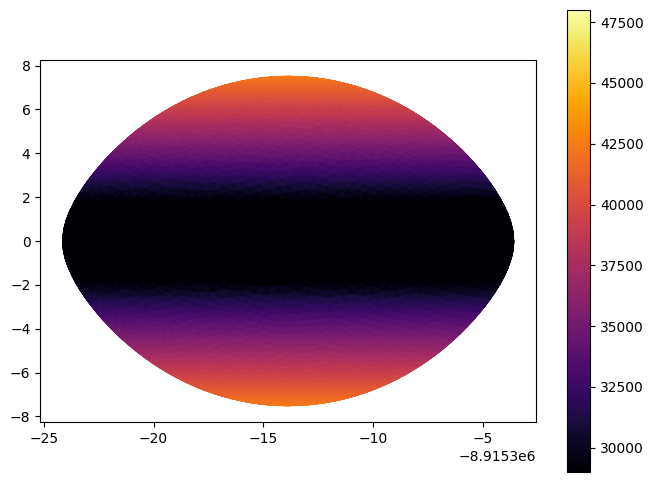

In [6]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = teffs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.inferno(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.inferno(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='inferno'), ax=axs)
plt.show()

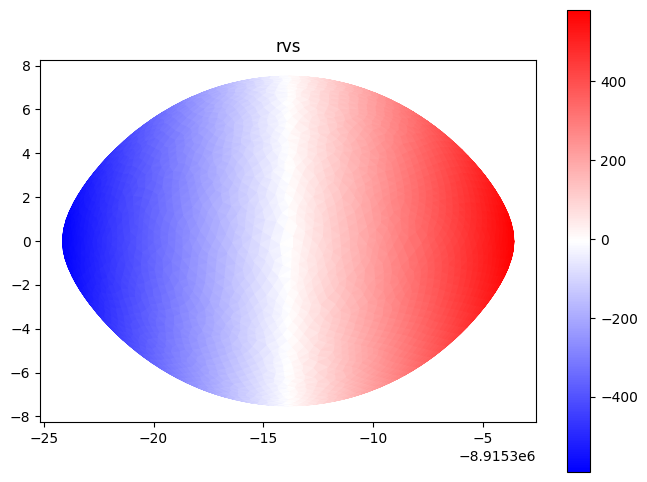

In [7]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = rvs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('rvs')
plt.show()

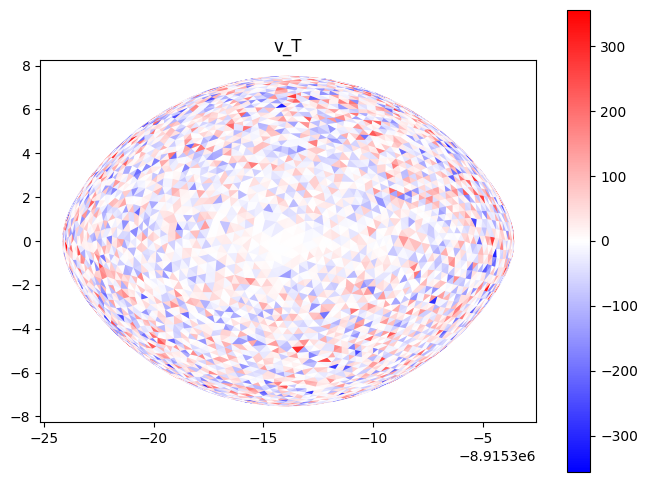

In [8]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_T = np.random.normal(0, 250, size=inds.shape[0])

#rng = np.random.default_rng(30)
#theta_T = rng.vonmises(mu=10, kappa=1.0* np.pi, size=mus.shape[0])

theta_T = np.random.uniform(0, 2*np.pi, size=inds.shape[0])
theta_mu = np.arccos(mus)
v_T = 0.5 * zeta_T * np.sin(theta_mu) * np.cos(theta_T)


fc = v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_T')
plt.show()

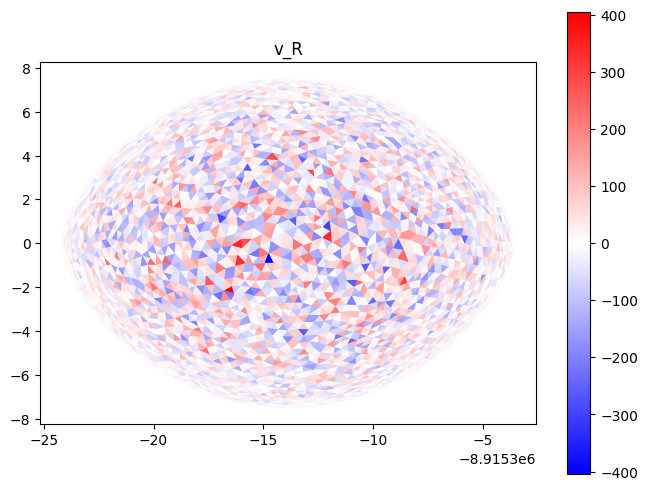

In [9]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_R = np.random.normal(0, 250, size=inds.shape[0])
v_R = 0.5 * zeta_R * mus


fc = v_R
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R')
plt.show()

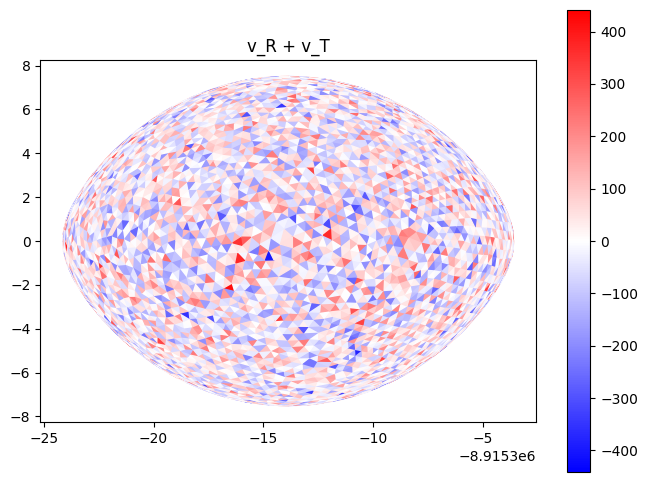

In [10]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R + v_T')
plt.show()

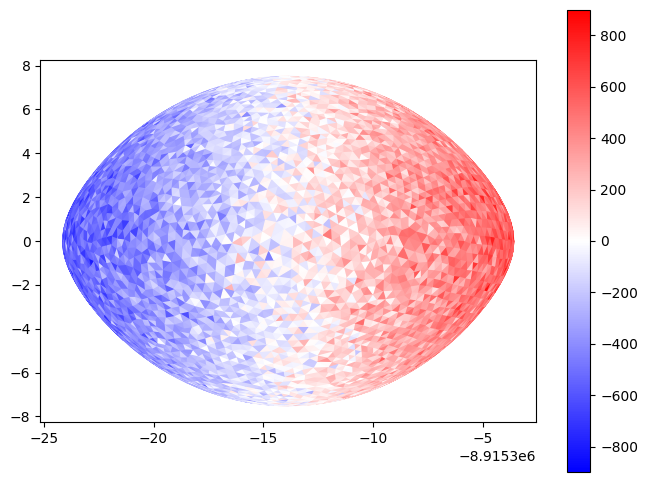

In [11]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T + rvs
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.show()

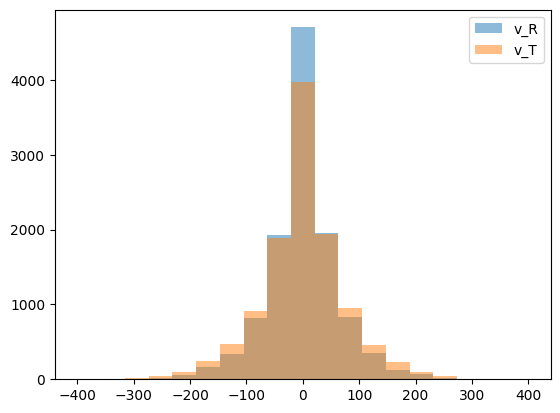

In [12]:
bins = np.linspace(-400, 400, 20)
plt.hist(v_R, alpha=0.5, bins=bins, label='v_R')
plt.hist(v_T, alpha=0.5, bins=bins, label='v_T')
plt.legend(loc='upper right')
plt.show()

In [13]:
print(np.std(v_R), np.std(v_T))

63.95411392461496 75.48722092996013


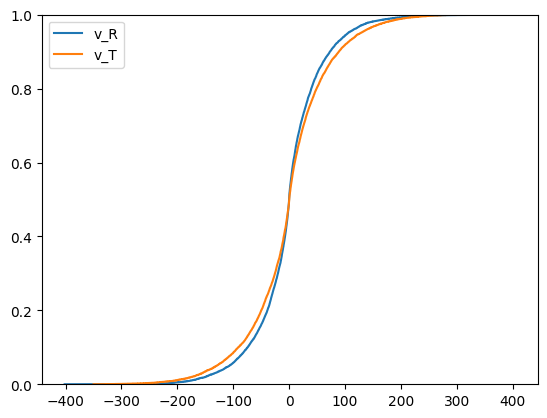

In [14]:
plt.ecdf(v_R, label='v_R')
plt.ecdf(v_T, label='v_T')
plt.legend(loc='upper left')
plt.show()

#### wrapping up together

In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
DEFAULT_TEMP_CMAP = "inferno"
DEFAULT_VEL_CMAP = "bwr"

def plot_total_velocity_field_with_hist(phcb,A_R=0.5,zeta_R_mean=0.0,zeta_R_std=150.0,zeta_T_mean=0.0,zeta_T_std=250.0,seed=None,figsize=(16, 5)):

    rng = np.random.default_rng(seed)
    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()
    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
    inds = (viss > 0)

    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus
    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)
    fc = v_R + v_T + rvs

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)
    fig, axs = plt.subplots(1, 2,figsize=figsize,gridspec_kw={'width_ratios': [1, 2]})

    pc = PolyCollection(polygons[inds][zinds],edgecolors=cm.bwr(norm(fc[inds][zinds])),facecolors=cm.bwr(norm(fc[inds][zinds])))
    axs[0].add_collection(pc)
    axs[0].set_aspect('equal')
    axs[0].axis('scaled')
    axs[0].set_title('Total local velocity field', fontsize=14)
    axs[0].set_xlabel('x', fontsize=12)
    axs[0].set_ylabel('y', fontsize=12)
    axs[0].tick_params(axis='both', which='major', labelsize=11)
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs[0], pad=0.02)
    cbar.set_label('Velocity', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]
    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)
    axs[1].hist( vR_vis,bins=bins,histtype='stepfilled',alpha=0.40,linewidth=1.5,label=r'$v_R$')
    axs[1].hist(vT_vis,bins=bins,histtype='stepfilled',alpha=0.40,linewidth=1.5,label=r'$v_T$')
    axs[1].hist(zetaR_vis,bins=bins,histtype='step',linewidth=2.0,linestyle='-',label=r'$\zeta_R$')
    axs[1].hist(zetaT_vis,bins=bins,histtype='step',linewidth=2.0,linestyle='--',label=r'$\zeta_T$')
    axs[1].axvline(0, color='k', ls='--', lw=1.0, alpha=0.7)
    axs[1].set_title('Intrinsic vs projected distributions', fontsize=14)
    axs[1].set_xlabel('Velocity', fontsize=12)
    axs[1].set_ylabel('Count', fontsize=12)
    axs[1].tick_params(axis='both', which='major', labelsize=11)
    axs[1].legend(frameon=False, fontsize=10)
    axs[1].grid(alpha=0.25, linestyle='--')

    plt.tight_layout()
    plt.show()

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T
    }

In [16]:

input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)
run_dictionaries = sp.create_runs_and_ids(fit_param_values)
run_dictionary = run_dictionaries[4]
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
phcb = s['%09.6f' % s['times@dataset@lc'].value]

Reading input file...


100%|██████████| 2/2 [00:01<00:00,  2.00it/s]


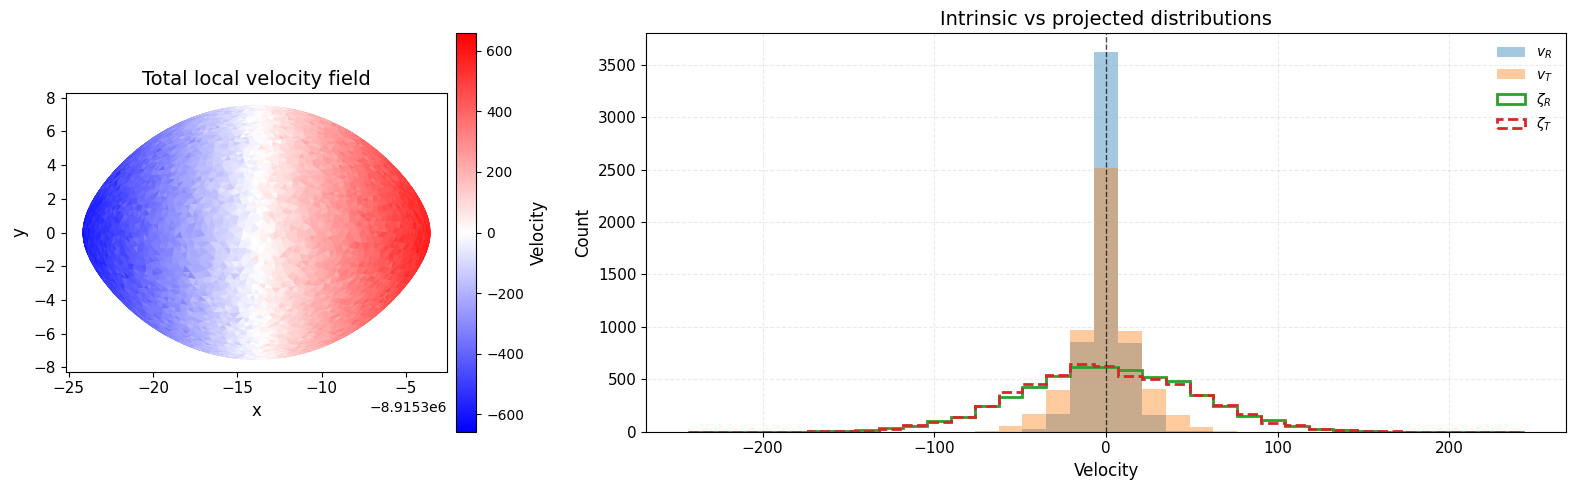

In [17]:
out = plot_total_velocity_field_with_hist(
    phcb,
    A_R=0.4,
    zeta_R_mean=0.0,
    zeta_R_std=50.0,
    zeta_T_mean=0.0,
    zeta_T_std=50.0, seed = None)

#### paramter study

In [18]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors

sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp

DEFAULT_TEMP_CMAP = "inferno"
DEFAULT_VEL_CMAP = "bwr"


def draw_velocity_surface_and_hist(
    phcb,
    ax_surface,
    ax_hist,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=150.0,
    zeta_T_mean=0.0,
    zeta_T_std=150.0,
    seed=None,
    row_label=None,
    show_colorbar=True
):
    rng = np.random.default_rng(seed)

    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()

    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)

    inds = (viss > 0)

    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus

    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)

    fc = v_R + v_T + rvs

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)

    pc = PolyCollection(
        polygons[inds][zinds],
        edgecolors=cm.bwr(norm(fc[inds][zinds])),
        facecolors=cm.bwr(norm(fc[inds][zinds]))
    )

    ax_surface.add_collection(pc)
    ax_surface.set_aspect('equal')
    ax_surface.axis('scaled')
    ax_surface.set_xlabel('x', fontsize=10)
    ax_surface.set_ylabel('y', fontsize=10)
    ax_surface.tick_params(axis='both', which='major', labelsize=9)

    if row_label is not None:
        ax_surface.set_title(row_label, fontsize=11)
    else:
        ax_surface.set_title('Total local velocity field', fontsize=11)

    if show_colorbar:
        cbar = ax_surface.figure.colorbar(
            cm.ScalarMappable(norm=norm, cmap='bwr'),
            ax=ax_surface,
            pad=0.02
        )
        cbar.set_label('Velocity', fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]

    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)

    ax_hist.hist(vR_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_R$')
    ax_hist.hist(vT_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_T$')
    ax_hist.hist(zetaR_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='-', label=r'$\zeta_R$')
    ax_hist.hist(zetaT_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='--', label=r'$\zeta_T$')
    ax_hist.axvline(0, color='k', ls='--', lw=1.0, alpha=0.7)

    sigma_vR = np.std(vR_vis)
    sigma_vT = np.std(vT_vis)

    txt = (
        rf'$\sigma(v_R)={sigma_vR:.1f}$' '\n'
        rf'$\sigma(v_T)={sigma_vT:.1f}$'
    )

    ax_hist.text(
        0.03, 0.97, txt,
        transform=ax_hist.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7')
    )

    ax_hist.set_title('Intrinsic vs projected distributions', fontsize=11)
    ax_hist.set_xlabel('Velocity', fontsize=10)
    ax_hist.set_ylabel('Count', fontsize=10)
    ax_hist.tick_params(axis='both', which='major', labelsize=9)
    ax_hist.legend(frameon=False, fontsize=8)
    ax_hist.grid(alpha=0.25, linestyle='--')

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T,
        'sigma_vR_vis': sigma_vR,
        'sigma_vT_vis': sigma_vT,
    }

In [19]:
def plot_total_velocity_field_with_hist(
    phcb,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=250.0,
    zeta_T_mean=0.0,
    zeta_T_std=250.0,
    seed=None,
    figsize=(16, 2)
):
    fig, axs = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={'width_ratios': [1, 2]}
    )

    out = draw_velocity_surface_and_hist(
        phcb=phcb,
        ax_surface=axs[0],
        ax_hist=axs[1],
        A_R=A_R,
        zeta_R_mean=zeta_R_mean,
        zeta_R_std=zeta_R_std,
        zeta_T_mean=zeta_T_mean,
        zeta_T_std=zeta_T_std,
        seed=seed,
        row_label='Total local velocity field',
        show_colorbar=True
    )

    plt.tight_layout()
    plt.show()
    return out

In [20]:
def sigma_parameter_study(
    phcb,
    sigma_list=[50, 100, 150, 250, 300, 350, 400, 450, 500],
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_T_mean=0.0,
    seed=None,
    figsize_per_row=(16, 2)):
    nrows = len(sigma_list)

    fig, axs = plt.subplots(
        nrows, 2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        gridspec_kw={'width_ratios': [1, 2]}
    )

    if nrows == 1:
        axs = np.array([axs])

    outputs = []

    for i, sigma in enumerate(sigma_list):
        out = draw_velocity_surface_and_hist(
            phcb=phcb,
            ax_surface=axs[i, 0],
            ax_hist=axs[i, 1],
            A_R=A_R,
            zeta_R_mean=zeta_R_mean,
            zeta_R_std=sigma,
            zeta_T_mean=zeta_T_mean,
            zeta_T_std=sigma,
            seed=seed,
            row_label=rf'$\sigma_R = \sigma_T = {sigma}$',
            show_colorbar=True
        )
        outputs.append(out)

    plt.tight_layout()
    plt.show()

    return outputs

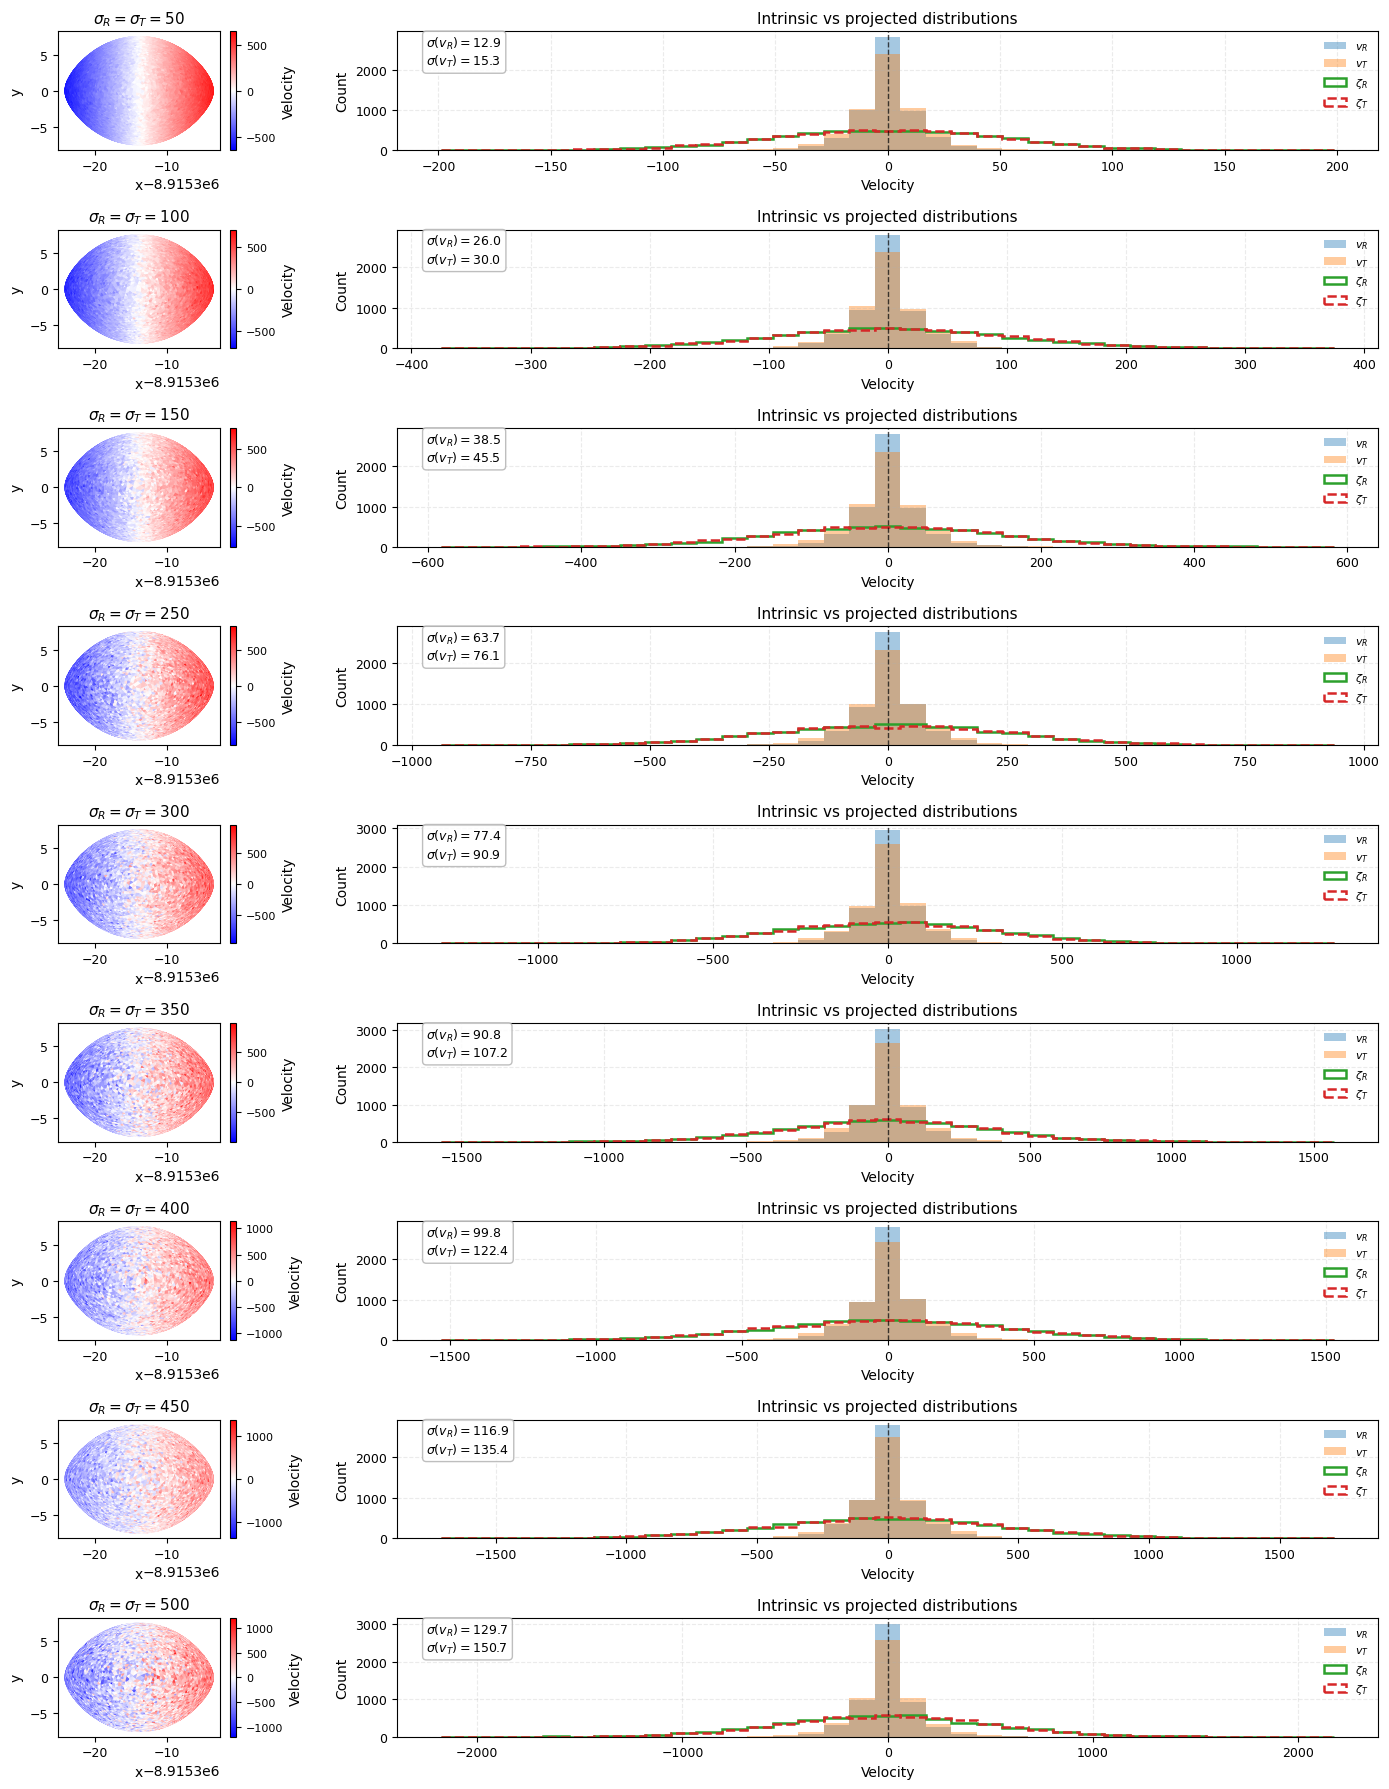

In [21]:
sigma_outputs = sigma_parameter_study(
    phcb,
    sigma_list=[50, 100, 150, 250, 300, 350, 400, 450, 500],
    A_R=0.5,
    seed=None
)

In [22]:
def rotation_parameter_study(
    input_file,
    vcrit_list=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.5,
    zeta_sigma=200.0,
    seed=None,
    figsize_per_row=(16, 2)
):
    fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
    times, obs_specs = sp.get_obs_spec_and_times(io_dict)

    nrows = len(vcrit_list)
    fig, axs = plt.subplots(
        nrows, 2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        gridspec_kw={'width_ratios': [1, 2]}
    )

    if nrows == 1:
        axs = np.array([axs])

    outputs = []

    for i, vcrit in enumerate(vcrit_list):
        fit_params_this = copy.deepcopy(fit_param_values)
        fit_params_this['v_crit_frac'] = [vcrit]

        run_dicts_this = sp.create_runs_and_ids(fit_params_this)
        run_dictionary = run_dicts_this[0]
        print(run_dictionary)
        
        s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
        phcb = s['%09.6f' % s['times@dataset@lc'].value]

        out = draw_velocity_surface_and_hist(
            phcb=phcb,
            ax_surface=axs[i, 0],
            ax_hist=axs[i, 1],
            A_R=A_R,
            zeta_R_mean=0.0,
            zeta_R_std=zeta_sigma,
            zeta_T_mean=0.0,
            zeta_T_std=zeta_sigma,
            seed=seed,
            row_label=rf'$v_{{\rm crit}} = {vcrit:.1f}$',
            show_colorbar=True
        )
        outputs.append({
            'v_crit_frac': vcrit,
            'out': out,
        })

    plt.tight_layout()
    plt.show()

    return outputs

Reading input file...
{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:01<00:00,  1.19it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.1, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:00<00:00,  2.04it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.2, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


...

100%|██████████| 2/2 [00:01<00:00,  1.54it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.8, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:01<00:00,  1.23it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.9, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


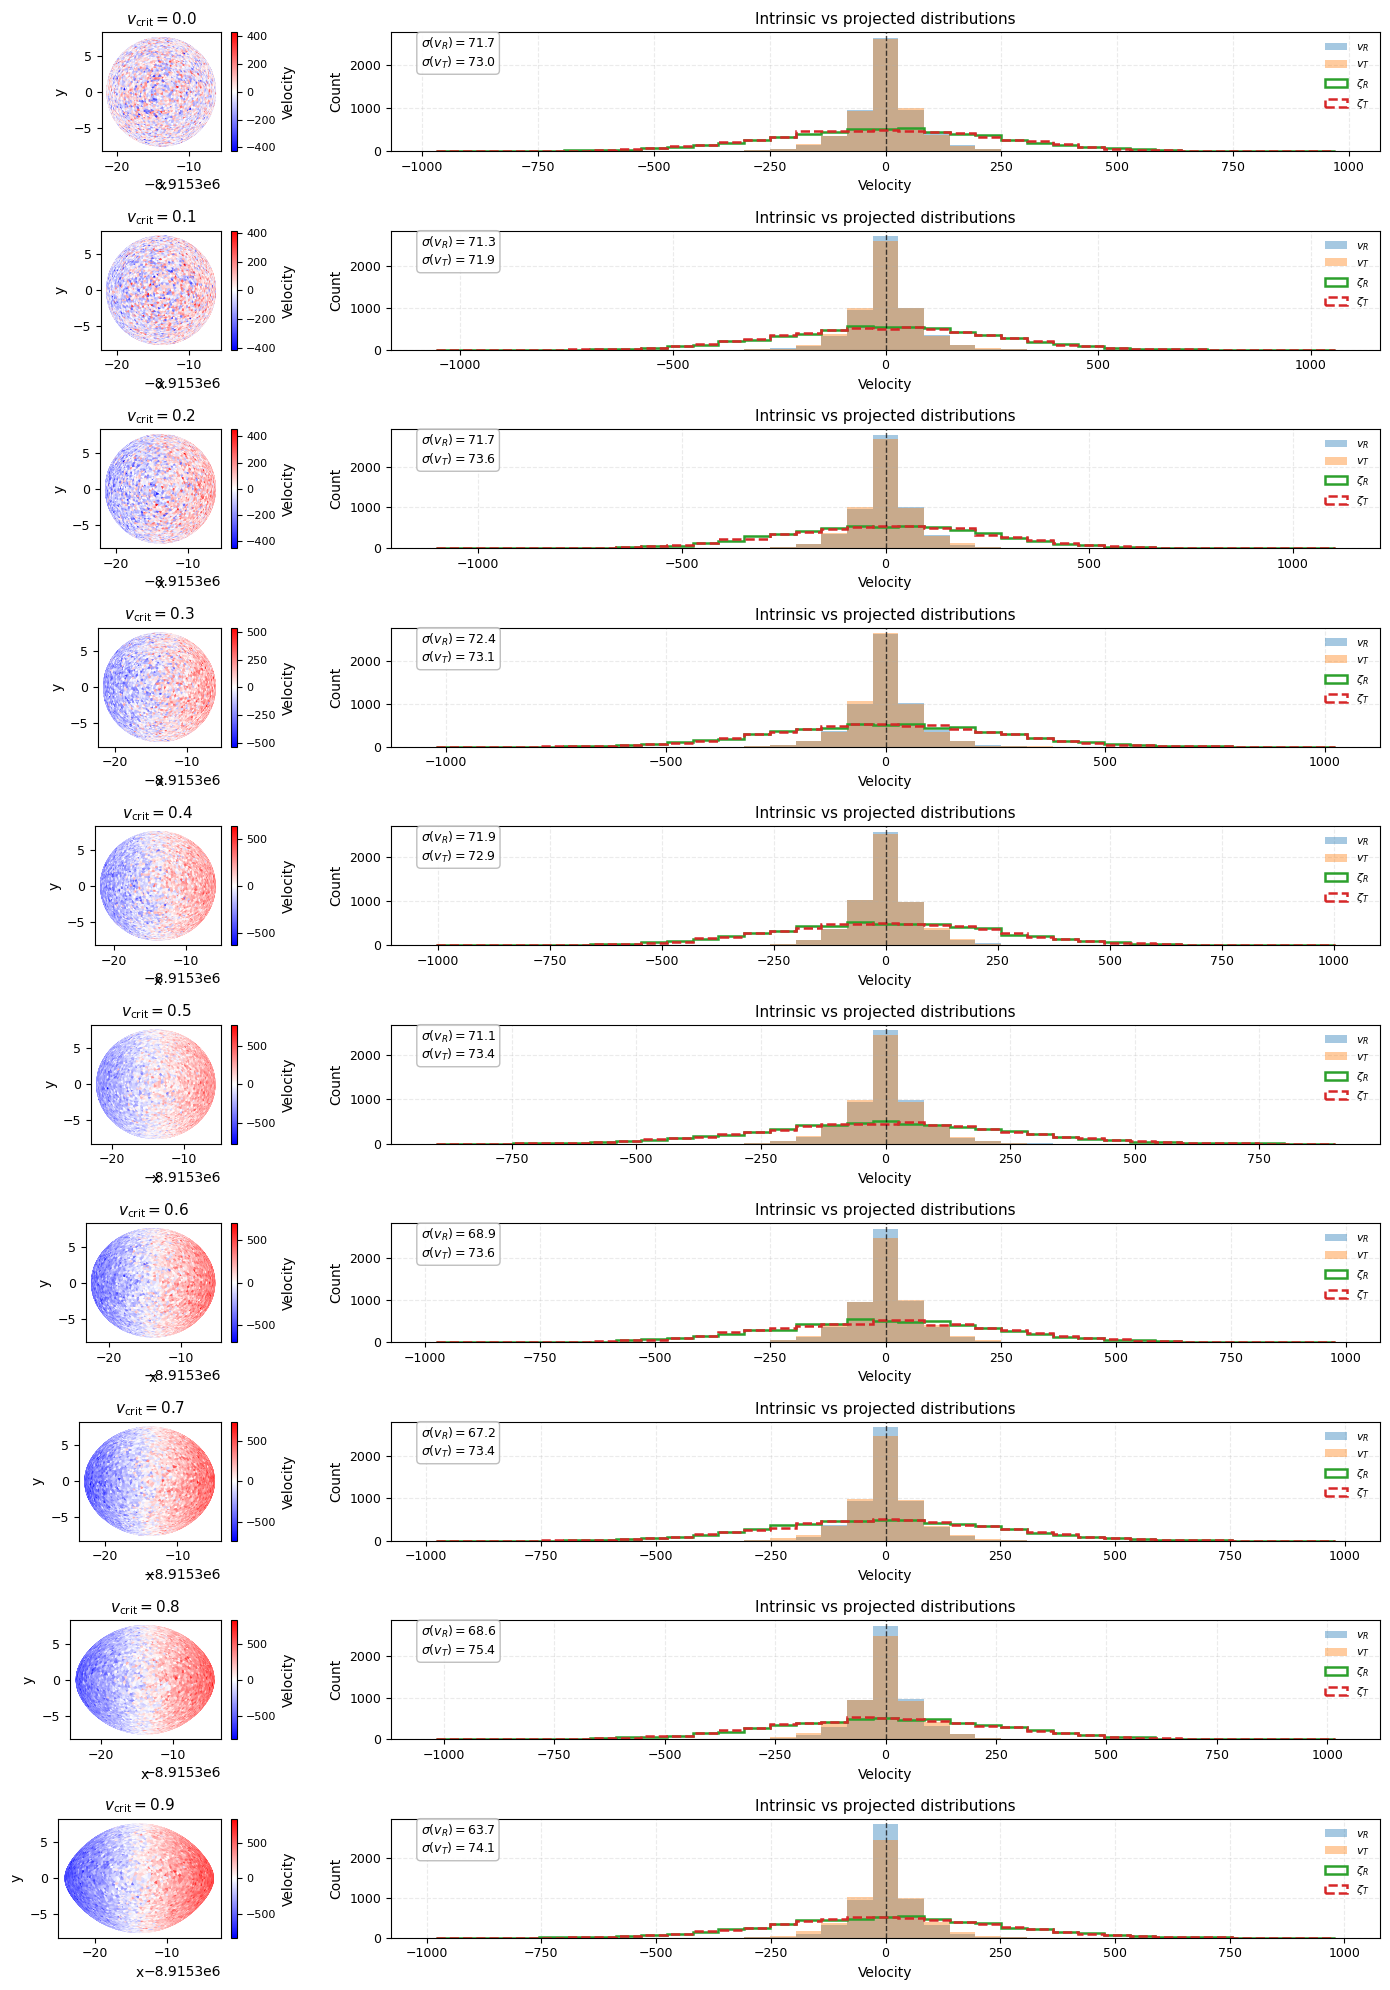

In [23]:
rot_outputs = rotation_parameter_study(
    input_file='/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt',
    vcrit_list=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.5,
    zeta_sigma=250.0,
    seed=None
)

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors
import numpy as np


def draw_velocity_hist_with_surface_inset(
    phcb,
    ax_hist,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=150.0,
    zeta_T_mean=0.0,
    zeta_T_std=250.0,
    seed=None,
    panel_label=None,
    inset_width="32%",
    inset_height="32%"
):
    rng = np.random.default_rng(seed)

    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()

    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
    inds = (viss > 0)

    # ---------------------------------------------------------
    # Velocity field generation
    # ---------------------------------------------------------
    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus

    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)

    fc = v_R + v_T + rvs

    # ---------------------------------------------------------
    # Histogram panel
    # ---------------------------------------------------------
    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]

    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)

    ax_hist.hist(vR_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_R$')
    ax_hist.hist(vT_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_T$')
    ax_hist.hist(zetaR_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='-', label=r'$\zeta_R$')
    ax_hist.hist(zetaT_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='--', label=r'$\zeta_T$')
    ax_hist.axvline(0, color='k', ls='--', lw=0.9, alpha=0.7)

    sigma_vR = np.std(vR_vis)
    sigma_vT = np.std(vT_vis)

    info_text = (
        rf'$\sigma(v_R)={sigma_vR:.1f}$' '\n'
        rf'$\sigma(v_T)={sigma_vT:.1f}$'
    )

    ax_hist.text(
        0.98, 0.97, info_text,
        transform=ax_hist.transAxes,
        ha='right', va='top',
        fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7')
    )

    if panel_label is not None:
        ax_hist.set_title(panel_label, fontsize=10)

    ax_hist.set_xlabel('Velocity', fontsize=9)
    ax_hist.set_ylabel('Count', fontsize=9)
    ax_hist.tick_params(axis='both', which='major', labelsize=8)
    ax_hist.grid(alpha=0.25, linestyle='--')
    ax_hist.legend(frameon=False, fontsize=7, loc='upper left', bbox_to_anchor=(0.0, 0.68))

    # ---------------------------------------------------------
    # Inset surface map
    # ---------------------------------------------------------
    ax_inset = inset_axes(ax_hist, width=inset_width, height=inset_height, loc='upper left', borderpad=0.8)

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)

    pc = PolyCollection(
        polygons[inds][zinds],
        edgecolors=cm.bwr(norm(fc[inds][zinds])),
        facecolors=cm.bwr(norm(fc[inds][zinds]))
    )

    ax_inset.add_collection(pc)
    ax_inset.set_aspect('equal')
    ax_inset.axis('scaled')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_facecolor('white')
    for spine in ax_inset.spines.values():
        spine.set_linewidth(0.8)

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T,
        'sigma_vR_vis': sigma_vR,
        'sigma_vT_vis': sigma_vT,
    }

In [25]:
def inclination_rotation_grid_study(
    input_file,
    inclinations=[10, 20, 30, 40, 50, 60, 70, 80, 90],
    vcrit_list=[0.3, 0.5, 0.7, 0.9],
    A_R=0.4,
    zeta_sigma=200.0,
    seed=None,
    figsize=(18, 26)
):
    fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
    times, obs_specs = sp.get_obs_spec_and_times(io_dict)

    nrows = len(inclinations)
    ncols = len(vcrit_list)

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        squeeze=False
    )

    outputs = []

    for i, inc in enumerate(inclinations):
        row_outputs = []

        for j, vcrit in enumerate(vcrit_list):
            fit_params_this = copy.deepcopy(fit_param_values)
            fit_params_this['inclination'] = [inc]
            fit_params_this['v_crit_frac'] = [vcrit]

            run_dicts_this = sp.create_runs_and_ids(fit_params_this)
            run_dictionary = run_dicts_this[0]

            s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
            phcb = s['%09.6f' % s['times@dataset@lc'].value]

            ax_hist = axs[i, j]

            panel_label = rf'$i={inc}^\circ,\ v_{{\rm crit}}={vcrit:.1f}$'

            out = draw_velocity_hist_with_surface_inset(
                phcb=phcb,
                ax_hist=ax_hist,
                A_R=A_R,
                zeta_R_mean=0.0,
                zeta_R_std=zeta_sigma,
                zeta_T_mean=0.0,
                zeta_T_std=zeta_sigma,
                seed=seed,
                panel_label=panel_label
            )

            row_outputs.append({
                'inclination': inc,
                'v_crit_frac': vcrit,
                'out': out
            })

        outputs.append(row_outputs)

    plt.tight_layout()
    plt.show()

    return outputs

In [ ]:
inc_rot_outputs = inclination_rotation_grid_study(
    input_file='/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt',
    inclinations=[10, 20, 30, 40, 50, 60, 70, 80, 90],
    vcrit_list=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.5,
    zeta_sigma=200.0,
    seed=None,
    figsize=(30, 24)
)

In [28]:
inc_rot_outputs

[[{'inclination': 10,
   'v_crit_frac': 0.1,
   'out': {'v_R': array([  0.56224515,  -0.9930988 ,   1.35023846, ...,  39.01715477,
             2.68330349, -17.57309334]),
    'v_T': array([-114.91919542,   -8.40889203,   -0.51978382, ...,  139.06908535,
             42.31307627,  -56.5928376 ]),
    'v_total': array([-103.84164904,    1.11328592,   11.34576076, ...,  172.62883957,
             39.29490214,  -80.16584887]),
    'zeta_R': array([-104.31163578,   64.58248105, -134.18794044, ...,  217.37744892,
             15.68375245, -103.02786819]),
    'zeta_T': array([ 348.07217208,   58.98957667,    1.04704096, ..., -311.50806497,
           -207.35053899, -226.60108473]),
    'theta_T': array([2.29208982, 4.42314001, 3.25944413, ..., 2.84603976, 4.2630724 ,
           1.01058282]),
    'sigma_vR_vis': 58.01397900911666,
    'sigma_vT_vis': 56.27880082977043}},
  {'inclination': 10,
   'v_crit_frac': 0.2,
   'out': {'v_R': array([  0.47774676,  -2.88055862,  -0.84602396, ..., -18.5

In [29]:
def make_sigma_difference_heatmap(inc_rot_outputs):
    """
    Build a single heatmap of:

        Delta = sigma(v_R) - sigma(v_T)

    Interpretation:
        Delta > 0  -> radial component dominates  (red)
        Delta < 0  -> tangential component dominates (blue)

    directly from the already computed inc_rot_outputs.
    """

    # ---------------------------------------------------------
    # Extract inclination + vcrit labels
    # ---------------------------------------------------------
    inclinations = [row[0]['inclination'] for row in inc_rot_outputs]
    vcrit_list = [cell['v_crit_frac'] for cell in inc_rot_outputs[0]]

    nrows = len(inclinations)
    ncols = len(vcrit_list)

    sigma_vR_grid = np.full((nrows, ncols), np.nan)
    sigma_vT_grid = np.full((nrows, ncols), np.nan)

    # ---------------------------------------------------------
    # Extract sigma values from stored outputs
    # ---------------------------------------------------------
    for i, row in enumerate(inc_rot_outputs):
        for j, cell in enumerate(row):
            sigma_vR_grid[i, j] = cell['out']['sigma_vR_vis']
            sigma_vT_grid[i, j] = cell['out']['sigma_vT_vis']

    # ---------------------------------------------------------
    # Main diagnostic:
    # positive  -> radial dominates
    # negative  -> tangential dominates
    # ---------------------------------------------------------
    delta_sigma_grid = sigma_vR_grid - sigma_vT_grid

    # Symmetric colour scale around zero
    vmax = np.max(np.abs(delta_sigma_grid))

    # ---------------------------------------------------------
    # Plot heatmap
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(
        delta_sigma_grid,
        origin='lower',
        aspect='auto',
        cmap='bwr',          # blue = negative, red = positive
        vmin=-vmax,
        vmax=vmax
    )

    # Axis labels
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels(vcrit_list, fontsize=11)

    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels(inclinations, fontsize=11)

    ax.set_xlabel(r'$v_{\rm crit}$ fraction', fontsize=13)
    ax.set_ylabel(r'Inclination ($^\circ$)', fontsize=13)

    ax.set_title(
        r'$\sigma(v_R) - \sigma(v_T)$',
        fontsize=15
    )

    # ---------------------------------------------------------
    # Write numerical values inside each cell
    # ---------------------------------------------------------
    for i in range(nrows):
        for j in range(ncols):
            value = delta_sigma_grid[i, j]

            ax.text(
                j, i,
                f"{value:.1f}",
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

    # ---------------------------------------------------------
    # Colorbar
    # ---------------------------------------------------------
    cbar = fig.colorbar(im, ax=ax)

    cbar.set_label(
        r'$\sigma(v_R) - \sigma(v_T)$',
        fontsize=12
    )

    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

    return {
        'inclinations': inclinations,
        'vcrit_list': vcrit_list,
        'sigma_vR_grid': sigma_vR_grid,
        'sigma_vT_grid': sigma_vT_grid,
        'delta_sigma_grid': delta_sigma_grid
    }

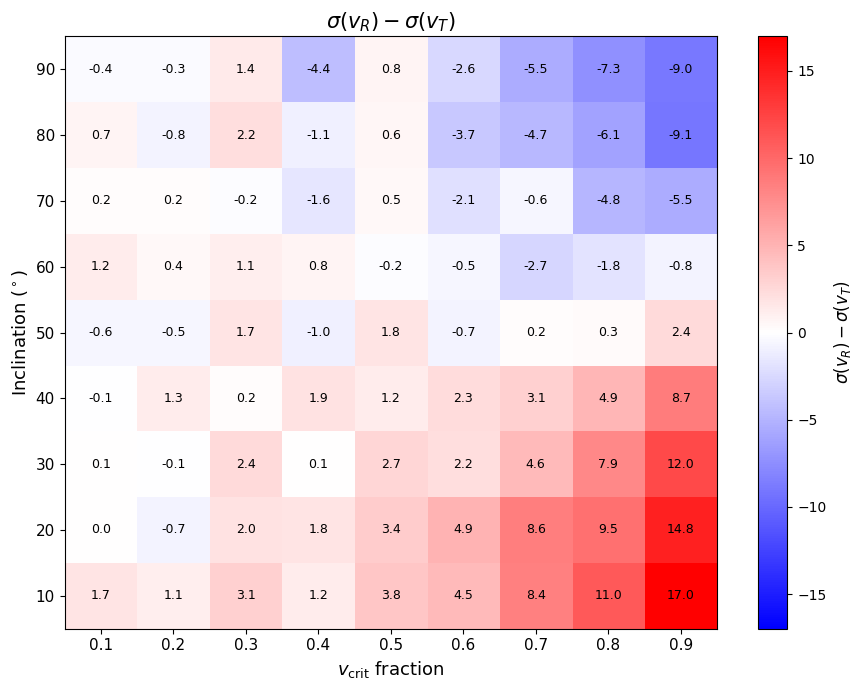

In [30]:
heatmap_results = make_sigma_difference_heatmap(inc_rot_outputs)

In [41]:
def make_sigma_vs_vcrit_heatmaps(inc_rot_outputs):

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize

    # ---------------------------------------------------------
    # Extract all values
    # ---------------------------------------------------------
    inclinations = []
    vcrit_vals = []
    sigma_vR_vals = []
    sigma_vT_vals = []

    for row in inc_rot_outputs:
        for cell in row:
            inc = cell['inclination']
            vcrit = cell['v_crit_frac']

            sigma_vR = cell['out']['sigma_vR_vis']
            sigma_vT = cell['out']['sigma_vT_vis']

            inclinations.append(inc)
            vcrit_vals.append(vcrit)
            sigma_vR_vals.append(sigma_vR)
            sigma_vT_vals.append(sigma_vT)

    inclinations = np.array(inclinations)
    vcrit_vals = np.array(vcrit_vals)
    sigma_vR_vals = np.array(sigma_vR_vals)
    sigma_vT_vals = np.array(sigma_vT_vals)

    # ---------------------------------------------------------
    # Colormap normalization by inclination
    # ---------------------------------------------------------
    norm = Normalize(
        vmin=np.min(inclinations),
        vmax=np.max(inclinations)
    )

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    fig, axs = plt.subplots(
        1, 2,
        figsize=(14, 6),
        sharex=True
    )

    # ---------------------------------------------------------
    # Left: sigma(v_R)
    # ---------------------------------------------------------
    sc1 = axs[0].scatter(
        vcrit_vals,
        sigma_vR_vals,
        c=inclinations,
        cmap='viridis',
        norm=norm,
        s=140,
        edgecolor='k',
        linewidth=0.6,
        alpha=0.9
    )

    axs[0].set_xlabel(r'$v_{\rm crit}$ fraction', fontsize=13)
    axs[0].set_ylabel(r'$\sigma(v_R)$', fontsize=13)
    axs[0].set_title(r'Projected radial component', fontsize=14)
    axs[0].tick_params(axis='both', labelsize=11)
    axs[0].grid(alpha=0.25, linestyle='--')

    # ---------------------------------------------------------
    # Right: sigma(v_T)
    # ---------------------------------------------------------
    sc2 = axs[1].scatter(
        vcrit_vals,
        sigma_vT_vals,
        c=inclinations,
        cmap='viridis',
        norm=norm,
        s=140,
        edgecolor='k',
        linewidth=0.6,
        alpha=0.9
    )

    axs[1].set_xlabel(r'$v_{\rm crit}$ fraction', fontsize=13)
    axs[1].set_ylabel(r'$\sigma(v_T)$', fontsize=13)
    axs[1].set_title(r'Projected tangential component', fontsize=14)
    axs[1].tick_params(axis='both', labelsize=11)
    axs[1].grid(alpha=0.25, linestyle='--')

    # ---------------------------------------------------------
    # Shared colorbar for inclination
    # ---------------------------------------------------------
    cbar = fig.colorbar(
        sc2,
        ax=axs.ravel().tolist(),
        location='right',
        fraction=0.035,
        pad=0.04
    )

    cbar.set_label(
        r'Inclination ($^\circ$)',
        fontsize=12
    )

    cbar.ax.tick_params(labelsize=10)
    #plt.tight_layout()
    plt.show()

    return {
        "inclinations": inclinations,
        "vcrit_vals": vcrit_vals,
        "sigma_vR_vals": sigma_vR_vals,
        "sigma_vT_vals": sigma_vT_vals
    }

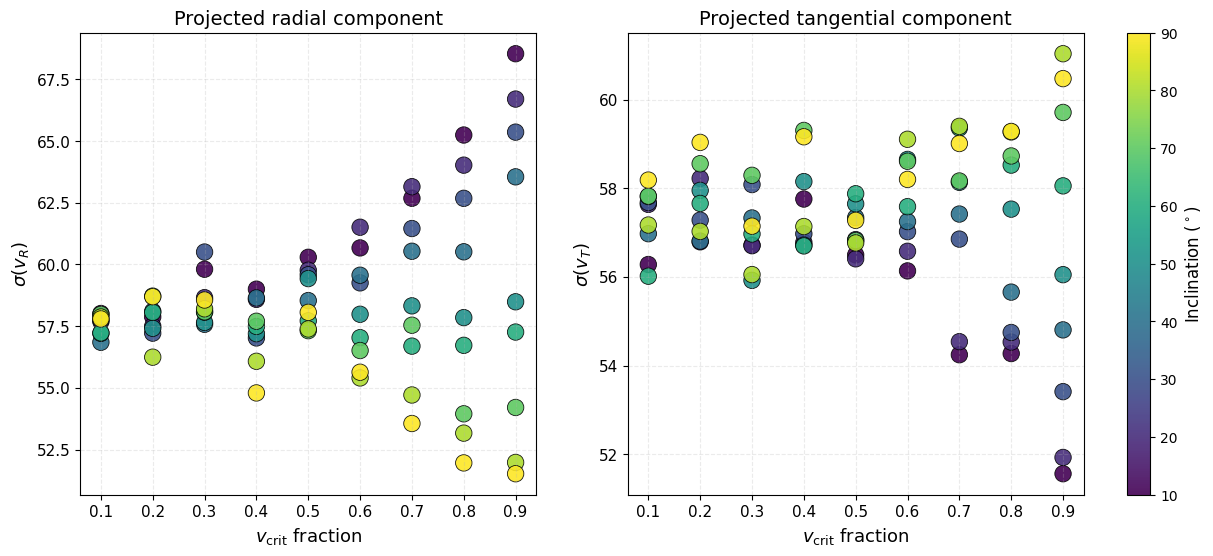

In [42]:
sigma_corr_out = make_sigma_vs_vcrit_heatmaps(inc_rot_outputs)

#### can we answer the vsini mac correlation?

In [59]:
import numpy as np
import matplotlib.pyplot as plt


def mock_observed_projected_rotation(inc_rot_outputs, n_per_vcrit=1000, rng_seed=42):
    """
    Build a mock observed sample from the theoretical inclination-vcrit grid,
    assuming uniform cos(i), and compute the projected-rotation proxy:

        x_obs = vcrit_frac * sin(i)

    This is proportional to vsini / vcrit for a fixed stellar model.
    """
    rng = np.random.default_rng(rng_seed)

    inclinations = np.array([row[0]['inclination'] for row in inc_rot_outputs], dtype=float)
    vcrit_list   = np.array([cell['v_crit_frac'] for cell in inc_rot_outputs[0]], dtype=float)

    n_i = len(inclinations)
    n_v = len(vcrit_list)

    sigma_vR_grid = np.full((n_i, n_v), np.nan)
    sigma_vT_grid = np.full((n_i, n_v), np.nan)

    for i, row in enumerate(inc_rot_outputs):
        for j, cell in enumerate(row):
            sigma_vR_grid[i, j] = cell['out']['sigma_vR_vis']
            sigma_vT_grid[i, j] = cell['out']['sigma_vT_vis']

    all_inc = []
    all_vcrit = []
    all_xobs = []
    all_sigma_vR = []
    all_sigma_vT = []

    # sample inclinations with uniform cos(i)
    cos_min = np.cos(np.radians(np.max(inclinations)))
    cos_max = np.cos(np.radians(np.min(inclinations)))

    for j, vcrit in enumerate(vcrit_list):
        cos_i = rng.uniform(cos_min, cos_max, size=n_per_vcrit)
        inc_sample = np.degrees(np.arccos(cos_i))
        sin_i = np.sin(np.radians(inc_sample))

        sigma_vR_sample = np.interp(inc_sample, inclinations, sigma_vR_grid[:, j])
        sigma_vT_sample = np.interp(inc_sample, inclinations, sigma_vT_grid[:, j])

        xobs = vcrit * sin_i

        all_inc.append(inc_sample)
        all_vcrit.append(np.full(n_per_vcrit, vcrit))
        all_xobs.append(xobs)
        all_sigma_vR.append(sigma_vR_sample)
        all_sigma_vT.append(sigma_vT_sample)

    return {
        "inclination": np.concatenate(all_inc),
        "vcrit": np.concatenate(all_vcrit),
        "xobs": np.concatenate(all_xobs),   # = vcrit_frac * sin(i)
        "sigma_vR": np.concatenate(all_sigma_vR),
        "sigma_vT": np.concatenate(all_sigma_vT),
        "grid_inclinations": inclinations,
        "grid_vcrit": vcrit_list,
        "sigma_vR_grid": sigma_vR_grid,
        "sigma_vT_grid": sigma_vT_grid,
    }


def plot_sigma_vs_projected_rotation(mock_obs, alpha=0.22, s=14):
    """
    Plot sigma(vR) and sigma(vT) against the observable proxy
    x = vcrit_frac * sin(i).
    """
    xobs = mock_obs["xobs"]
    sigR = mock_obs["sigma_vR"]
    sigT = mock_obs["sigma_vT"]
    inc  = mock_obs["inclination"]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    sc1 = axs[0].scatter(
        xobs, sigR,
        c=inc, cmap='viridis',
        s=s, alpha=alpha, edgecolors='none'
    )
    axs[0].set_xlabel(r'$v_{\rm crit}\sin i$', fontsize=13)
    axs[0].set_ylabel(r'$\sigma(v_R)$', fontsize=13)
    axs[0].set_title(r'Projected radial component', fontsize=14)
    axs[0].grid(alpha=0.25, linestyle='--')
    axs[0].tick_params(axis='both', labelsize=11)

    sc2 = axs[1].scatter(
        xobs, sigT,
        c=inc, cmap='viridis',
        s=s, alpha=alpha, edgecolors='none'
    )
    axs[1].set_xlabel(r'$v_{\rm crit}\sin i$', fontsize=13)
    axs[1].set_ylabel(r'$\sigma(v_T)$', fontsize=13)
    axs[1].set_title(r'Projected tangential component', fontsize=14)
    axs[1].grid(alpha=0.25, linestyle='--')
    axs[1].tick_params(axis='both', labelsize=11)

    cbar = fig.colorbar(sc2, ax=axs, pad=0.02)
    cbar.set_label(r'Inclination ($^\circ$)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    #plt.subplots_adjust(wspace=0.20, right=0.90)
    plt.show()


def plot_sigma_vs_projected_rotation_summary(mock_obs):
    """
    Summarize the mock observed relation by binning in xobs = vcrit*sin(i)
    and plotting median + 16th/84th percentiles.
    """
    xobs = mock_obs["xobs"]
    sigR = mock_obs["sigma_vR"]
    sigT = mock_obs["sigma_vT"]

    bins = np.linspace(np.min(xobs), np.max(xobs), 10)
    xc = 0.5 * (bins[:-1] + bins[1:])

    medR, p16R, p84R = [], [], []
    medT, p16T, p84T = [], [], []

    for b1, b2 in zip(bins[:-1], bins[1:]):
        mask = (xobs >= b1) & (xobs < b2)

        valsR = sigR[mask]
        valsT = sigT[mask]

        if len(valsR) == 0:
            medR.append(np.nan); p16R.append(np.nan); p84R.append(np.nan)
            medT.append(np.nan); p16T.append(np.nan); p84T.append(np.nan)
        else:
            medR.append(np.median(valsR))
            p16R.append(np.percentile(valsR, 16))
            p84R.append(np.percentile(valsR, 84))

            medT.append(np.median(valsT))
            p16T.append(np.percentile(valsT, 16))
            p84T.append(np.percentile(valsT, 84))

    medR = np.array(medR); p16R = np.array(p16R); p84R = np.array(p84R)
    medT = np.array(medT); p16T = np.array(p16T); p84T = np.array(p84T)

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    axs[0].plot(xc, medR, marker='o')
    axs[0].fill_between(xc, p16R, p84R, alpha=0.3)
    axs[0].set_xlabel(r'$v_{\rm crit}\sin i$', fontsize=13)
    axs[0].set_ylabel(r'$\sigma(v_R)$', fontsize=13)
    axs[0].set_title(r'Mock observed $\sigma(v_R)$ trend', fontsize=14)
    axs[0].grid(alpha=0.25, linestyle='--')

    axs[1].plot(xc, medT, marker='o')
    axs[1].fill_between(xc, p16T, p84T, alpha=0.3)
    axs[1].set_xlabel(r'$v_{\rm crit}\sin i$', fontsize=13)
    axs[1].set_ylabel(r'$\sigma(v_T)$', fontsize=13)
    axs[1].set_title(r'Mock observed $\sigma(v_T)$ trend', fontsize=14)
    axs[1].grid(alpha=0.25, linestyle='--')

    for ax in axs:
        ax.tick_params(axis='both', labelsize=11)

    #plt.subplots_adjust(wspace=0.20)
    plt.show()


def plot_sigma_hist_and_cdf(mock_obs, bins=35):
    """
    Histogram + CDF of sigma(vR) and sigma(vT) for the full mock observed sample.
    """
    sigR = np.asarray(mock_obs["sigma_vR"])
    sigT = np.asarray(mock_obs["sigma_vT"])

    fig, axs = plt.subplots(2, 2, figsize=(12, 9))

    axs[0, 0].hist(sigR, bins=bins, histtype='stepfilled', alpha=0.55, linewidth=1.5)
    axs[0, 0].set_xlabel(r'$\sigma(v_R)$', fontsize=12)
    axs[0, 0].set_ylabel('Count', fontsize=12)
    axs[0, 0].set_title(r'Histogram of $\sigma(v_R)$', fontsize=13)
    axs[0, 0].grid(alpha=0.25, linestyle='--')

    axs[0, 1].hist(sigT, bins=bins, histtype='stepfilled', alpha=0.55, linewidth=1.5)
    axs[0, 1].set_xlabel(r'$\sigma(v_T)$', fontsize=12)
    axs[0, 1].set_ylabel('Count', fontsize=12)
    axs[0, 1].set_title(r'Histogram of $\sigma(v_T)$', fontsize=13)
    axs[0, 1].grid(alpha=0.25, linestyle='--')

    xR = np.sort(sigR)
    yR = np.arange(1, len(xR) + 1) / len(xR)
    axs[1, 0].plot(xR, yR, linewidth=2)
    axs[1, 0].set_xlabel(r'$\sigma(v_R)$', fontsize=12)
    axs[1, 0].set_ylabel('CDF', fontsize=12)
    axs[1, 0].set_title(r'CDF of $\sigma(v_R)$', fontsize=13)
    axs[1, 0].grid(alpha=0.25, linestyle='--')

    xT = np.sort(sigT)
    yT = np.arange(1, len(xT) + 1) / len(xT)
    axs[1, 1].plot(xT, yT, linewidth=2)
    axs[1, 1].set_xlabel(r'$\sigma(v_T)$', fontsize=12)
    axs[1, 1].set_ylabel('CDF', fontsize=12)
    axs[1, 1].set_title(r'CDF of $\sigma(v_T)$', fontsize=13)
    axs[1, 1].grid(alpha=0.25, linestyle='--')

    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=11)

    plt.subplots_adjust(wspace=0.25, hspace=0.28)
    plt.show()

In [ ]:
mock_obs = mock_observed_projected_rotation(
    inc_rot_outputs,
    n_per_vcrit=2000,
    rng_seed=42
)

plot_sigma_vs_projected_rotation(mock_obs)
plot_sigma_vs_projected_rotation_summary(mock_obs)
plot_sigma_hist_and_cdf(mock_obs, bins=35)